# Lab 4: Urban Flood Vulnerability Mapping with the HAND Model — Pennsylvania

**Name:** Qiwen Bian  **Date:** 2026-09-07

This notebook estimates potential inundation depth across Pennsylvania using the USGS 1-arc-second (~30 m) DEM and the **Height Above Nearest Drainage (HAND)** model implemented in `pysheds`. HAND measures, for every cell, its vertical distance above the nearest drainage channel; cells with small HAND values are more prone to flooding.

**Workflow:** (0) download data, (1) wrap the pipeline into a function, (2) loop over all PA tiles, (3) mosaic the per-tile results into a statewide inundation map.

## Step0: Download data

### 1. define function

In [1]:
import requests, os, math

In [2]:
def get_tile_name(lat, lon):
    lat_tile = f"n{int(abs(lat)):02d}" if lat >= 0 else f"s{int(abs(lat)):02d}"
    lon_tile = f"w{int(abs(lon)):03d}" if lon < 0 else f"e{int(abs(lon)):03d}"
    return f"{lat_tile}{lon_tile}"

In [3]:
def get_tiles_in_bbox(min_lat, max_lat, min_lon, max_lon):
    tile_list = []
    for lat in range(math.ceil(min_lat), math.ceil(max_lat) + 1):
        for lon in range(math.ceil(-min_lon), math.ceil(-max_lon) + 1):
            tile_list.append(f"n{lat:02d}w{lon_w:03d}")
    return tile_list

In [4]:
def download_dem_1arc(tile_name, save_path="."):
    base_url = "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1/TIFF/current"
    url = f"{base_url}/{tile_name}/USGS_1_{tile_name}.tif"
    output_file = os.path.join(save_path, f"{tile_name}.tif")
    if os.path.exists(output_file):
        return
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(output_file, "wb") as f:
            for chunk in response.iter_content(1024):
                f.write(chunk)
        print(f" {tile_name} done")
    else:
        print(f" {tile_name} not exist")

### 2. download

In [5]:
save_directory = "dem-pa"
os.makedirs(save_directory, exist_ok=True)

tiles = get_tiles_in_bbox(39.72, 42.27, -80.52, -74.69)
print(f"total number: {len(tiles)} :", tiles)

for tile in tiles:
    download_dem_1arc(tile, save_directory)

total number: 0 : []


### 3. test

In [6]:
import glob, rasterio
files = sorted(glob.glob(f"{save_directory}/*.tif"))
print(f"succeed: {len(files)} / {len(tiles)} ")
ds = rasterio.open(files[0])
print(ds.crs, ds.bounds, ds.shape)

succeed: 18 / 0 
EPSG:4269 BoundingBox(left=-75.00166666698243, bottom=38.99833333361735, right=-73.99833333361576, top=40.00166666698402) (3612, 3612)


## Step1: Relative functions

### 1. parameters

In [7]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from pysheds.grid import Grid
import rasterio
from rasterio.merge import merge

In [8]:
DEM_DIR = 'dem-pa'
OUT_DIR = 'hand-pa'
THRESHOLD = 3.0
ACC_THRESHOLD = 200
DIRMAP = (64, 128, 1, 2, 4, 8, 16, 32)

os.makedirs(OUT_DIR, exist_ok=True)

### 2. full pipeline function

In [9]:
def process_tile(tif_path, out_dir=OUT_DIR, threshold=THRESHOLD, acc_threshold=ACC_THRESHOLD):
    out_path = os.path.join(out_dir, os.path.basename(tif_path))

    if os.path.exists(out_path):
        print('already exists:', os.path.basename(tif_path))
        return None

    grid = Grid.from_raster(tif_path)
    dem = grid.read_raster(tif_path)

    pit_filled = grid.fill_pits(dem)
    depression_filled = grid.fill_depressions(pit_filled)
    inflated = grid.resolve_flats(depression_filled)

    fdir = grid.flowdir(inflated, dirmap=DIRMAP)
    acc = grid.accumulation(fdir, dirmap=DIRMAP)

    hand = grid.compute_hand(fdir, dem, acc > acc_threshold)
    inundation = np.where((hand >= 0) & (hand < threshold), threshold - hand, np.nan)

    meta = rasterio.open(tif_path).meta.copy()
    meta.update(dtype='float32', count=1, compress='lzw', nodata=np.nan)
    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(inundation.astype('float32'), 1)

    print('done:', os.path.basename(tif_path))
    return out_path

### 3. loop over PA

In [10]:
tiles = sorted(glob.glob(os.path.join(DEM_DIR, '*.tif')))
print(len(tiles), 'tiles found')

outputs = []
for i , tif_path in enumerate(tiles, start=1):
    out = process_tile(tif_path)
    if out:
        outputs.append(out)
    print(f'[{i}/{len(tiles)}] finished, {len(outputs)} newly processed')

18 tiles found
already exists: n40w075.tif
[1/18] finished, 0 newly processed
already exists: n40w076.tif
[2/18] finished, 0 newly processed
already exists: n40w077.tif
[3/18] finished, 0 newly processed
already exists: n40w078.tif
[4/18] finished, 0 newly processed
already exists: n40w079.tif
[5/18] finished, 0 newly processed
already exists: n40w080.tif
[6/18] finished, 0 newly processed
already exists: n41w075.tif
[7/18] finished, 0 newly processed
already exists: n41w076.tif
[8/18] finished, 0 newly processed
already exists: n41w077.tif
[9/18] finished, 0 newly processed
already exists: n41w078.tif
[10/18] finished, 0 newly processed
already exists: n41w079.tif
[11/18] finished, 0 newly processed
already exists: n41w080.tif
[12/18] finished, 0 newly processed
already exists: n42w075.tif
[13/18] finished, 0 newly processed
already exists: n42w076.tif
[14/18] finished, 0 newly processed
already exists: n42w077.tif
[15/18] finished, 0 newly processed
already exists: n42w078.tif
[16/18

### 4. Mosaic the per-tile results into a statewide GeoTIFF

In [11]:
output_files = sorted(glob.glob(os.path.join(OUT_DIR, 'n??w???.tif')))
print(len(output_files), 'result tiles to mosaic')

datasets = [rasterio.open(f) for f in output_files]

mosaic_arr, mosaic_transform = merge(datasets)
print('mosaic shape:', mosaic_arr.shape)

out_meta = datasets[0].meta.copy()
out_meta.update(driver='GTiff',
               height=mosaic_arr.shape[1],
               width=mosaic_arr.shape[2],
               count=1,
               dtype='float32',
               transform=mosaic_transform,
               compress='lzw',
               nodata=np.nan)

with rasterio.open('PA_inundation.tif', 'w', **out_meta) as dst:
    dst.write(mosaic_arr)

for ds in datasets:
    ds.close()

print('saved PA_inundation.tif')

18 result tiles to mosaic
mosaic shape: (1, 10812, 21612)
saved PA_inundation.tif


### 5. Build statewide inundation map

full size: 21612 x 10812 | CRS: EPSG:4269


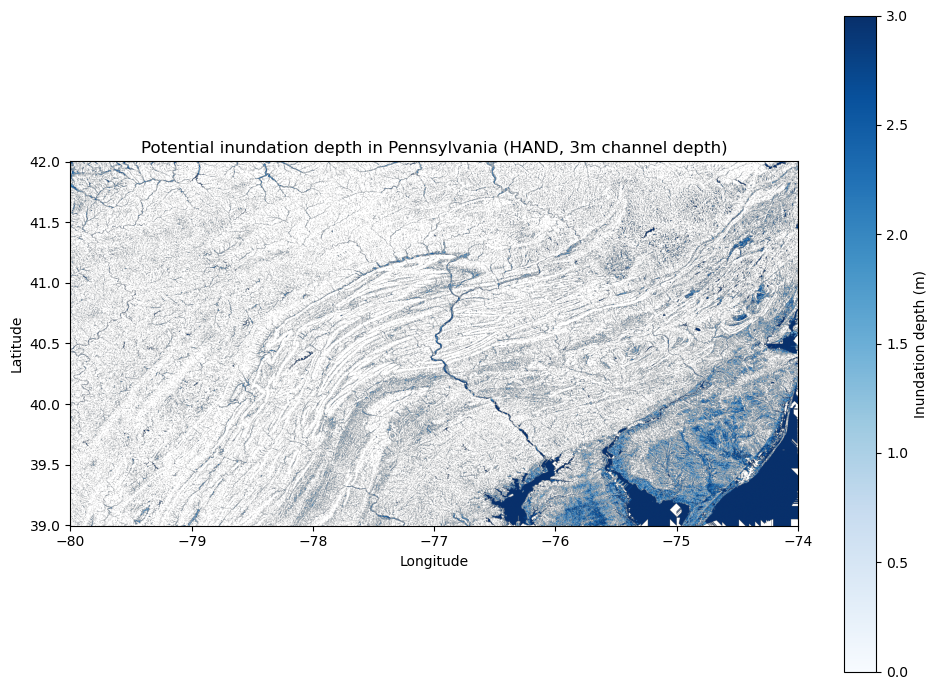

In [12]:
factor = 8
with rasterio.open('PA_inundation.tif') as src:
    overview = src.read(1, out_shape=(src.height // factor, src.width // factor))
    bounds = src.bounds
    print('full size:', src.width, 'x', src.height, '| CRS:', src.crs)

plt.figure(figsize=(10, 7))
plt.imshow(overview, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
          cmap='Blues', vmin=0, vmax=THRESHOLD)
plt.colorbar(label='Inundation depth (m)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('Potential inundation depth in Pennsylvania (HAND, %dm channel depth)' % THRESHOLD)
plt.tight_layout()
plt.savefig('PA_inundation_map.png', dpi=300)
plt.show()

### 6. Discussion

The two governing parameters are the assumed channel depth (3 m) and the
channel-definition threshold (accumulation > 200 cells). Raising the channel
depth to 5 m extends the inundation footprint to every cell with HAND < 5 m
and visibly enlarges the flooded area. Lowering the accumulation threshold
treats even smaller headwater streams as channels, which increases drainage
density and draws more valley floors into the inundated zone; this is why
about 22% of the mapped footprint shows potential inundation, and raising the
threshold (e.g., to 1,000 cells) would confine the map to larger rivers.

Several limitations apply. The constant-channel-depth assumption ignores
hydraulic routing: real flood depths vary with discharge and channel geometry,
so a uniform 3 m likely overstates risk along small streams while understating
it on large rivers during severe events. Because each tile was processed
independently, flow accumulation stops at tile boundaries, which makes HAND
values near tile edges less reliable for rivers that cross them. Ocean and
no-data boundaries also produce negative HAND values that had to be masked
with a HAND >= 0 guard — a data issue that does not arise in the instructor's
inland demonstration area. Finally, the rectangular mosaic includes
neighboring-state areas that clipping to the Pennsylvania boundary would remove.

In [13]:
import rasterio, numpy as np
with rasterio.open('PA_inundation.tif') as src:
    a = src.read(1)
print(np.isfinite(a).mean())

0.2225090339775747
